# Kohn-Sham inversion calculations

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  22/08/2025  
**Last modified:**  04/09/2026

## 1. Introduction

In this tutorial, I will present examples of Kohn-Sham (KS) inversion calculations. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting potentials and densities, accessing eigenvalues, density errors, etc.

---

For a short but great overview of inverse KS methods, I recommend reading the following article:  
> Y. Shi, A. Wasserman, Inverse Kohn–Sham density functional theory: progress and challenges – J. Phys. Chem. Lett. 12, 22 (2021) 5308-5318. [link](https://doi.org/10.1021/acs.jpclett.1c00752)

The implementation of KS inversion follows the so-called response function approach proposed in:
> A. Görling, Kohn-Sham potentials and wave functions from electron densities – Phys. Rev. A 46 (1992) 3753. [link](https://link.aps.org/doi/10.1103/PhysRevA.46.3753)

The actual implementation is described in the following publications:
> J. Erhard, E. Trushin, A. Görling, Numerically stable inversion approach to construct Kohn-Sham potentials for given electron densities within a Gaussian basis set framework – J. Chem. Phys. 156 (2022) 204124. [link](https://doi.org/10.1063/5.0087356)  
> J. Erhard, E. Trushin, A. Görling, Kohn-Sham inversion for open-shell systems within the response function approach – J. Chem. Phys. 162, 034116 (2025). [link](https://doi.org/10.1063/5.0239422)  
> S. Fauser, E. Trushin, A. Görling, Highly precise values for the energy ratios underlying the Lieb–Oxford bound and the convexity conjecture for the adiabatic connection – J. Chem. Phys. 162, 164108 (2025). [link](https://doi.org/10.1063/5.0263582) 

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

Kohn-Sham inversion calculations requires to specify two basis sets, namely orbital and OEP basis sets. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange-correlation potential. 
Gaussian basis set KS inversion methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets.
Present implementation of KS inversion uses a preprocessing of the auxiliary basis set that enables such balancing in an automatic fashion for standard Gaussian basis sets.
The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  | $5 \cdot 10^{-2}$   |
| aug-cc-pwCVQZ  | $1.7 \cdot 10^{-2}$ |
| aug-cc-pwCV5Z  | $5 \cdot 10^{-3}$   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X=T,Q,5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pyscf import cc, dft, fci, gto, scf

from methods.ksinv import KSINV
from methods.osksinv import OSKSINV
from utils.coulomb_potential_on_grid import coulomb_potential_on_grid
from utils.gen_coords_1d import gen_coords_1d
from utils.make_augmented_aux_basis import make_augmented_aux_basis
from utils.relaxed_ccsd import cc_rrdm1

matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

## 2. Kohn-Sham inversion for closed-shell systems
In the closed-shell case, the KS inversion determines the KS potential $v_s$ for a given target or reference density $\rho_{ref}$. Note that I use the terms target density and reference density interchangeably throughout the tutorial.  
KS potential $v_s$ is the sum of the external potential of the physical electron system $v_{ext}$, here the electrostatic potential of the nuclei, the Hartree potential $v_H$, the classical electrostatic potential of the electron density $\rho_{ref}$, and the exchange-correlation potential $v_{xc}$.
$$v_s = v_{ext} + v_H + v_{xc}$$
Since $v_{ext}$ and $v_H$ are known, the KS inversion essentially determines the exchange-correlation potential $v_{xc}$, which we will plot/analyze instead of $v_s$.

### 2.1 Kohn-Sham inversion for H$_2$ molecule using FCI density

We start with the KS inversion of the closed-shell molecule, H$_2$, using the target density from the FCI calculation. We will plot the resulting exchange, correlation, and exchange-correlation potentials along the bond axis.  

In [2]:
# Hartree-Fock calculation
mol = gto.M(atom="H 0. 0. 0.370946; H 0.0 0.0 -0.370946", basis="aug-cc-pVQZ", symmetry=False, verbose=0)
mf = scf.RHF(mol)
mf.run()

# FCI calculation
cisolver = fci.FCI(mf)
es, fcivec = cisolver.kernel()

In [3]:
# Create density matrix in AO representation
nelec_a = 1
nelec_b = 1
norb = mf.mo_coeff.shape[1]

dm_ref = cisolver.make_rdm1(fcivec, norb, (nelec_a, nelec_b))
dm_ref = mf.mo_coeff @ dm_ref @ mf.mo_coeff.T

In [4]:
# KS inversion
mf_inv = KSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ref, es)
mf_inv.run(maxit=100, thr_fai_oep=1.7e-2)

ITER        ENERGY            RHS        MIXING
  0     -1.152967607839    9.590e-03    1.000e-01
  1     -1.155045813851    8.631e-03    1.000e-01
  2     -1.156915892662    7.768e-03    1.000e-01
  3     -1.158598720991    6.991e-03    1.000e-01
  4     -1.160113074392    6.291e-03    1.320e-01
  5     -1.161911765165    5.461e-03    1.822e-01
  6     -1.164067088844    4.465e-03    2.646e-01
  7     -1.166625695910    3.284e-03    4.010e-01
  8     -1.169477011080    1.967e-03    6.080e-01
  9     -1.172065722587    7.711e-04    8.390e-01
 10     -1.173466162749    1.243e-04    9.738e-01
 11     -1.173727906993    3.399e-06    9.993e-01
 12     -1.173735028052    3.529e-08    1.000e+00
 13     -1.173735056426    9.180e-10    1.000e+00
 14     -1.173735056876    2.419e-11    1.000e+00
KS inversion converged

Total energy:              -1.173735056876
One-electron energy:       -2.507362616206
Two-electron energy:        0.660863171050
Nuclear energy:             0.713280653950
Coulom

Now we can plot resulting potentials. The exchange-correlation potential consists of a reference potential $v^{ref}$ and a remainder $v_{xc}^{rest}$:
$$v_{xc}=v^{ref}+v_{xc}^{rest}$$
We also have access to the exchange potential $v_x$ and the correlation potential $v_c$.

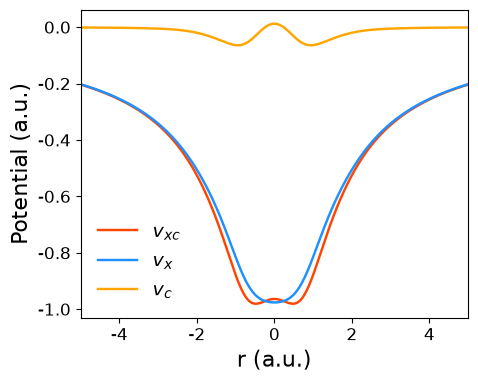

In [5]:
coords = gen_coords_1d(-15.0, 15.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv = vcoul_on_grid @ (mf_inv.vref_oep + mf_inv.vrest_oep)
vx_on_grid_ksinv = vcoul_on_grid @ mf_inv.vx_oep
vc_on_grid_ksinv = vcoul_on_grid @ mf_inv.vc_oep

plt.plot(coords[:, 2], vxc_on_grid_ksinv, color="orangered", label="$v_{xc}$")
plt.plot(coords[:, 2], vx_on_grid_ksinv, color="dodgerblue", label="$v_x$")
plt.plot(coords[:, 2], vc_on_grid_ksinv, color="orange", label="$v_c$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

The resulting exchange-correlation potential looks similar to those calculated with other KS inversion methods, see e.g.
> O.V. Gritsenko and E.J. Baerends, Effect of molecular dissociation on the exchange-correlation Kohn-Sham potential – Phys. Rev. A 54, 1957 (1996). [link](https://doi.org/10.1103/PhysRevA.54.1957)  
> B. Kanungo, P.M. Zimmerman, V. Gavini, Exact exchange-correlation potentials from ground-state electron densities – Nat. Commun. 10, 4497 (2019). [link](https://doi.org/10.1038/s41467-019-12467-0)

For the sake of illustration, we will plot the target and KS densities along the bond axis, as well as their difference. Note that `Density error` provides integrated density error defined as $N_{err} = \int|\rho_{KS}(\mathbf{r})-\rho_{ref}(\mathbf{r})|d\mathbf{r}$.

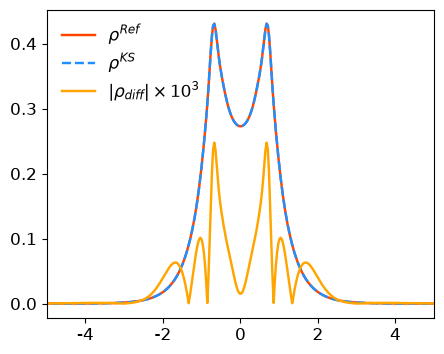

In [6]:
ao = dft.numint.eval_ao(mf.mol, coords)
den_ref = dft.numint.eval_rho(mf.mol, ao, dm_ref)
den_ks = dft.numint.eval_rho(mf.mol, ao, mf_inv.mf.make_rdm1())
plt.plot(coords[:, 2], den_ref, color="orangered", label="$\\rho^{Ref}$")
plt.plot(coords[:, 2], den_ks, "--", color="dodgerblue", label="$\\rho^{KS}$")
plt.plot(coords[:, 2], abs(den_ref - den_ks) * 1000.0, color="orange", label=r"$|\rho_{diff}| \times 10^3$")
plt.xlim(-5, 5)
plt.legend(frameon=False, fontsize=12, loc=2)
plt.show()

### 2.2 Kohn-Sham inversion for CO molecule using CCSD density

In [7]:
ORBITAL_BASIS = "aug-cc-pwCVTZ"
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False

mf = scf.RHF(mol)
mf.kernel()
print(f"Hartree-Fock total energy: {mf.e_tot:15.12f}")

mf_cc = cc.CCSD(mf)
mf_cc.kernel()
print(
    f"CCSD correlation energy:     {mf_cc.e_corr:15.12f}",
)
print(f"CCSD total energy:         {mf_cc.e_tot:15.12f}")
dm_ccsd_unrelaxed = mf_cc.make_rdm1(ao_repr=True)
dm_ccsd = cc_rrdm1(mf_cc)

Hartree-Fock total energy: -112.781919233520
CCSD correlation energy:     -0.469109286308
CCSD total energy:         -113.251028519828


In [8]:
# KS inversion
mf_inv = KSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ccsd, mf_cc.e_tot)
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY            RHS        MIXING
  0    -94.821223982286    8.448e-01    1.000e-01
  1    -96.675829478984    7.598e-01    1.000e-01
  2    -98.341200535986    6.835e-01    1.000e-01
  3    -99.837342742080    6.150e-01    1.000e-01
  4   -101.181882551120    5.535e-01    1.320e-01
  5   -102.774417408530    4.807e-01    1.821e-01
  6   -104.673393675597    3.938e-01    2.636e-01
  7   -106.910627742533    2.915e-01    3.970e-01
  8   -109.382214687851    1.786e-01    5.967e-01
  9   -111.632652931153    7.580e-02    8.205e-01
 10   -112.921003226876    1.667e-02    9.601e-01
 11   -113.221976791632    3.121e-03    9.925e-01
 12   -113.253626825135    7.810e-04    9.981e-01
 13   -113.259328544640    1.891e-04    9.995e-01
 14   -113.260432899634    4.698e-05    9.999e-01
 15   -113.260715818544    1.079e-05    1.000e+00
 16   -113.260769377335    2.784e-06    1.000e+00
 17   -113.260785142395    5.848e-07    1.000e+00
 18   -113.260787687661    1.683e-07    1.000e+00
 1

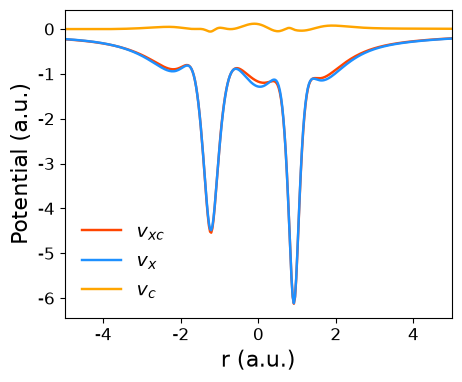

In [9]:
coords = gen_coords_1d(-15.0, 15.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv = vcoul_on_grid @ (mf_inv.vref_oep + mf_inv.vrest_oep)
vx_on_grid_ksinv = vcoul_on_grid @ mf_inv.vx_oep
vc_on_grid_ksinv = vcoul_on_grid @ mf_inv.vc_oep

plt.plot(coords[:, 2], vxc_on_grid_ksinv, color="orangered", label="$v_{xc}$")
plt.plot(coords[:, 2], vx_on_grid_ksinv, color="dodgerblue", label="$v_x$")
plt.plot(coords[:, 2], vc_on_grid_ksinv, color="orange", label="$v_c$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

In [10]:
# Function to make text in bold
def bold_text(text):
    return "\033[1m" + text + "\033[0m"


def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues, HOMO energy, and LUMO-HOMO gap.

    Args:
      eig: Eigenvalues.
      no: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    if len(eigs.shape) == 1:  # closed-shell case
        for i in range(nmax):
            eig = f"{eigs[i]:7.3f}"
            if i + 1 <= no:
                eig = bold_text(eig)
            print(f"{i + 1:2}   {eig}")
        print(f"HOMO:      {eigs[no - 1]:7.3f}")
        print(f"LUMO-HOMO: {eigs[no] - eigs[no - 1]:7.3f}")
    else:
        for i in range(nmax):
            ea = f"{eigs[0, i]:7.3f}"
            eb = f"{eigs[1, i]:7.3f}"
            if i + 1 <= no[0]:
                ea = bold_text(ea)
            if i + 1 <= no[1]:
                eb = bold_text(eb)
            if i + 1 <= nmax:
                print(f"{i + 1:2}   {ea}  {eb}")
        print(f"HOMO:       {eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1] - 1]:7.3f}")
        print(f"LUMO-HOMO:  {eigs[0, no[0]] - eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1]] - eigs[1, no[1] - 1]:7.3f}")

In [11]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 10)

 1   -19.060
 2   -10.203
 3    -1.214
 4    -0.652
 5    -0.563
 6    -0.563
 7    -0.460
 8    -0.196
 9    -0.196
10    -0.112
HOMO:       -0.460
LUMO-HOMO:   0.264


### 2.3 Kohn-Sham inversion for CO molecule using CCSD density with HOMO condition

With Gaussian basis set KS inversion, it might be difficult to obtain accurate orbital energy of highest occupied molecular orbital (HOMO). However, this orbital energy can be fixed to a known accurate value.

In [12]:
# KS inversion
mf_inv = KSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ccsd, mf_cc.e_tot, ip=0.515)
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY            RHS        MIXING
  0    -94.821223982286    7.904e-01    1.000e-01
  1   -108.830107020496    2.149e-01    1.000e-01
  2   -108.761109213561    1.831e-01    1.000e-01
  3   -109.204494358635    1.646e-01    1.000e-01
  4   -109.609033964268    1.483e-01    1.318e-01
  5   -110.087891226353    1.288e-01    1.816e-01
  6   -110.660072239229    1.055e-01    2.631e-01
  7   -111.336934182036    7.795e-02    3.975e-01
  8   -112.089519194122    4.716e-02    6.016e-01
  9   -112.776379623529    1.894e-02    8.323e-01
 10   -113.157600706933    3.212e-03    9.713e-01
 11   -113.234726450294    3.948e-04    9.965e-01
 12   -113.240237264873    6.083e-05    9.995e-01
 13   -113.241156840468    5.056e-05    9.995e-01
 14   -113.240901689212    1.483e-05    9.999e-01
 15   -113.240801372190    8.090e-07    1.000e+00
 16   -113.240799370200    7.162e-07    1.000e+00
 17   -113.240802622380    2.346e-08    1.000e+00
 18   -113.240803017641    4.094e-08    1.000e+00
 1

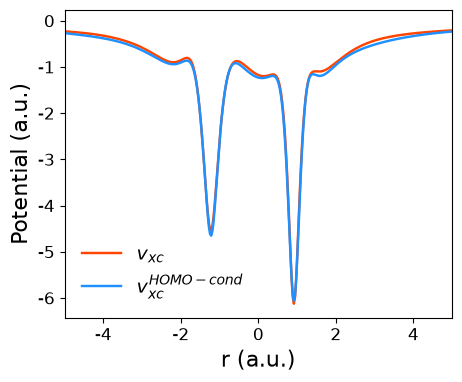

In [13]:
vxc_on_grid_ksinv_with_homo_condition = vcoul_on_grid @ (mf_inv.vref_oep + mf_inv.vrest_oep)

plt.plot(coords[:, 2], vxc_on_grid_ksinv, color="orangered", label="$v_{xc}$")
plt.plot(coords[:, 2], vxc_on_grid_ksinv_with_homo_condition, color="dodgerblue", label="$v_{xc}^{HOMO-cond}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

In [14]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 10)

 1   -19.114
 2   -10.269
 3    -1.273
 4    -0.711
 5    -0.623
 6    -0.623
 7    -0.515
 8    -0.253
 9    -0.253
10    -0.143
HOMO:       -0.515
LUMO-HOMO:   0.262


## 3. Kohn-Sham inversion for open-shell systems

A common way to perform standard or inverse KS calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for $\alpha$ and $\beta$ electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.  
Thus, in the spin-unrestricted case, the KS potentials $v_s^\alpha$ and $v_s^\beta$ for the $\alpha$ and $\beta$ spin are obtained by KS inversion:
$$v_s^\sigma = v_{ext} + v_H + v_{xc}^\sigma$$
with $\sigma = \alpha, \beta$.  
The target densities $\rho^\alpha$ and $\rho^\beta$ for $\alpha$ and $\beta$ electrons must be provided as input for KS inversion calculation.

An alternative approach is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems. In this case, the total electron density should be provided as input to KS inversion and one KS potential $v_s$ is determined:
$$v_s = v_{ext} + v_H + v_{xc}$$

### 3.1 Kohn-Sham inversion for Li atom using FCI density

First, we run FCI calculation and store the target density matrices.

In [15]:
mol = gto.M(atom="Li 0 0 0", basis="aug-cc-pVTZ", symmetry=False, verbose=0, spin=1)
mf = scf.UHF(mol)
mf.run()

cisolver = fci.FCI(mf)
es, fcivec = cisolver.kernel()

nelec_a = 2
nelec_b = 1
norb = mf.mo_coeff.shape[1]
dm1a, dm1b = cisolver.make_rdm1s(fcivec, norb, (nelec_a, nelec_b))
dm1a = mf.mo_coeff[0] @ dm1a @ mf.mo_coeff[0].T
dm1b = mf.mo_coeff[1] @ dm1b @ mf.mo_coeff[1].T
dm = np.stack((dm1a, dm1b))

#### 3.1.1 Spin-unrestricted KS inversion
Now we can perform spin-unrestricted KS inversion.

In [16]:
mf_inv = OSKSINV(mf, "cc-pVDZ-RIFIT", dm, es)
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY           RHS_a       RHS_b      MIXING_a    MIXING_b
  0     -7.052389042255    6.060e-02   3.146e-03   1.000e-01   1.000e-01
  1     -7.100180888793    5.456e-02   2.832e-03   1.000e-01   1.000e-01
  2     -7.143279915894    4.913e-02   2.549e-03   1.000e-01   1.000e-01
  3     -7.182140839061    4.423e-02   2.294e-03   1.000e-01   1.000e-01
  4     -7.217175206500    3.982e-02   2.065e-03   1.319e-01   1.320e-01
  5     -7.258789103011    3.459e-02   1.792e-03   1.818e-01   1.822e-01
  6     -7.308652599346    2.833e-02   1.466e-03   2.634e-01   2.644e-01
  7     -7.367866605773    2.090e-02   1.078e-03   3.983e-01   4.007e-01
  8     -7.434009243282    1.263e-02   6.463e-04   6.029e-01   6.075e-01
  9     -7.494630084758    5.055e-03   2.537e-04   8.333e-01   8.386e-01
 10     -7.528338738246    8.561e-04   4.100e-05   9.715e-01   9.737e-01
 11     -7.535027256468    2.596e-05   1.086e-06   9.991e-01   9.993e-01
 12     -7.535236166234    2.645e-07   8.718e-10   

Let's parse and print resulting eigenvalues.

In [17]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 5)

 1    -2.110   -2.455
 2    -0.241   -0.294
 3    -0.168   -0.231
 4    -0.168   -0.231
 5    -0.168   -0.231
HOMO:        -0.241    -2.455
LUMO-HOMO:    0.073     2.161


The electron configuration of Li in its ground state is $1s^22s^1$. There are two occupied $\alpha$ orbitals and one occupied $\beta$ orbital. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system.  
A special feature of the spin-unrestricted KS solution for the Li atom resulting from KS inversion, discussed in detail in [J. Chem. Phys. 120, 8364–8372 (2004)](https://doi.org/10.1063/1.1698561), is that the orbital energy of the lowest unoccupied $\beta$ orbital is lower than that of the highest occupied $\alpha$ orbital. Our calculation reproduces this feature.

Finally, let's plot $\alpha$ and $\beta$ exchange-correlation potentials.

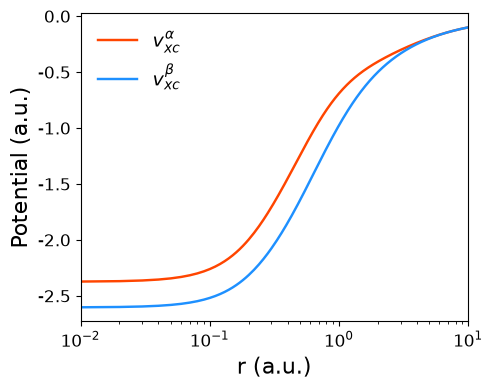

In [18]:
coords = gen_coords_1d(0.0, 10.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv_a = vcoul_on_grid @ (mf_inv.vrest_oep_a + mf_inv.vref_oep_a)
vxc_on_grid_ksinv_b = vcoul_on_grid @ (mf_inv.vrest_oep_b + mf_inv.vref_oep_b)

plt.plot(coords[:, 2], vxc_on_grid_ksinv_a, color="orangered", label="$v_{xc}^\\alpha$")
plt.plot(coords[:, 2], vxc_on_grid_ksinv_b, color="dodgerblue", label="$v_{xc}^\\beta$")
plt.xlim(0.01, 10)
plt.xscale("log")
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

#### 3.1.2 Spin-restricted KS inversion
Now we will perform the spin-restricted KS inversion for Li.

In [19]:
mf_inv = OSKSINV(
    mf, "cc-pVDZ-RIFIT", dm, es, spin_sym=True
)  # I use "cc-pVDZ-RIFIT" since "aug-cc-pVDZ-RIFIT" is not easily available
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY            RHS        MIXING
  0     -6.942007013660    7.783e-02   1.000e-01
  1     -7.004551601475    7.007e-02   1.000e-01
  2     -7.060923294848    6.309e-02   1.000e-01
  3     -7.111725632952    5.680e-02   1.000e-01
  4     -7.157504124524    5.113e-02   1.319e-01
  5     -7.211877083817    4.441e-02   1.818e-01
  6     -7.277025494296    3.637e-02   2.635e-01
  7     -7.354381048186    2.683e-02   3.986e-01
  8     -7.440745360888    1.619e-02   6.033e-01
  9     -7.519758188808    6.472e-03   8.338e-01
 10     -7.563495279098    1.098e-03   9.716e-01
 11     -7.572136281071    3.620e-05   9.991e-01
 12     -7.572424197769    7.669e-07   1.000e+00
 13     -7.572430210381    2.499e-08   1.000e+00
 14     -7.572430408542    5.547e-10   1.000e+00
 15     -7.572430412894    1.759e-11   1.000e+00
KS inversion converged

Total energy:              -7.572430412894
One-electron energy:       -9.798062101212
Two-electron energy:        2.376846978973
Nuclear energy:

In [20]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 5)

 1    -2.227   -2.227
 2    -0.257   -0.257
 3    -0.185   -0.185
 4    -0.185   -0.185
 5    -0.185   -0.185
HOMO:        -0.257    -2.227
LUMO-HOMO:    0.072     1.970


In contrast to the spin-unrestricted case, the spin-restricted KS inversion does not exhibit spin symmetry breaking leading to the same orbital energies in $\alpha$ and $\beta$ spin channels.

There is only one exchange-correlation potential that is the same in $\alpha$ and $\beta$ spin channels.

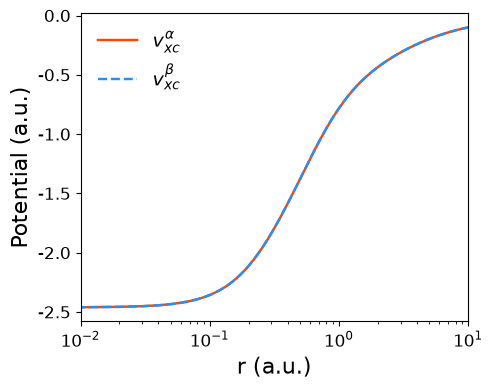

In [21]:
coords = gen_coords_1d(0.0, 10.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv_a = vcoul_on_grid @ (mf_inv.vrest_oep_a + mf_inv.vref_oep_a)
vxc_on_grid_ksinv_b = vcoul_on_grid @ (mf_inv.vrest_oep_b + mf_inv.vref_oep_b)

plt.plot(coords[:, 2], vxc_on_grid_ksinv_a, color="orangered", label="$v_{xc}^\\alpha$")
plt.plot(coords[:, 2], vxc_on_grid_ksinv_b, "--", color="dodgerblue", label="$v_{xc}^\\beta$")
plt.xlim(0.01, 10)
plt.xscale("log")
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

#### 3.1.3 Spin-unrestricted KS inversion with fixed HOMO eigenvalues
With Gaussian basis set KS inversion, it might be difficult to obtain accurate orbital energy of highest occupied molecular orbital (HOMO). However, this orbital energy can be fixed to a known accurate value. To do this we can specify ionization potentials for $\alpha$ and $\beta$ spin channels. In the case of one set of spatial orbitals, only ionization potential is used.

I will use values of `0.198121` and `2.36738` as ionization potentials for $\alpha$ and $\beta$ spin channels. This are values from FCI total energy difference calculations using aug-cc-pwCV5Z orbital basis set. Alternatively, ionization potentials from experiment can be used.

In [22]:
mf_inv = OSKSINV(
    mf, "cc-pVDZ-RIFIT", dm, es, ip=[0.198121, 2.36738]
)  # I use "cc-pVDZ-RIFIT" since "aug-cc-pVDZ-RIFIT" is not easily available
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY           RHS_a       RHS_b      MIXING_a    MIXING_b
  0     -7.052389042255    6.504e-02   1.800e-03   1.000e-01   1.000e-01
  1     -6.796981753933    7.759e-02   5.416e-03   1.000e-01   1.000e-01
  2     -6.852790175210    7.097e-02   4.895e-03   1.000e-01   1.000e-01
  3     -6.916270632091    6.393e-02   4.405e-03   1.000e-01   1.000e-01
  4     -6.973477672968    5.758e-02   3.963e-03   1.317e-01   1.321e-01
  5     -7.041386640335    5.006e-02   3.439e-03   1.813e-01   1.824e-01
  6     -7.122648321537    4.108e-02   2.811e-03   2.621e-01   2.650e-01
  7     -7.219020627545    3.044e-02   2.066e-03   3.950e-01   4.017e-01
  8     -7.326633534666    1.859e-02   1.236e-03   5.963e-01   6.088e-01
  9     -7.425682804321    7.689e-03   4.844e-04   8.247e-01   8.395e-01
 10     -7.481870391268    1.489e-03   7.842e-05   9.657e-01   9.738e-01
 11     -7.494038126901    1.259e-04   2.233e-06   9.971e-01   9.993e-01
 12     -7.494954620446    1.692e-05   1.429e-08   

In [23]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 5)

 1    -2.035   -2.367
 2    -0.198   -0.268
 3    -0.130   -0.200
 4    -0.130   -0.200
 5    -0.130   -0.200
HOMO:        -0.198    -2.367
LUMO-HOMO:    0.069     2.099


Now the HOMO eigenvalues are shifted to predefined values. There is a visible change in the form of the exchange correlation potential for the $\alpha$ spin.

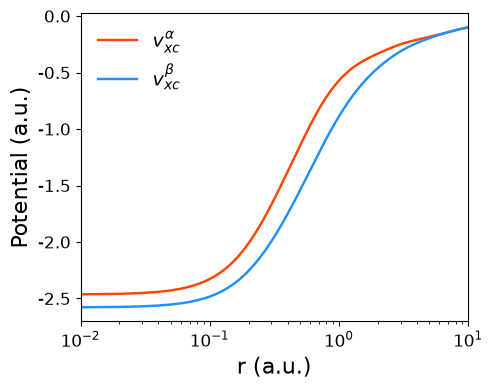

In [24]:
coords = gen_coords_1d(0.0, 10.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv_a = vcoul_on_grid @ (mf_inv.vrest_oep_a + mf_inv.vref_oep_a)
vxc_on_grid_ksinv_b = vcoul_on_grid @ (mf_inv.vrest_oep_b + mf_inv.vref_oep_b)

plt.plot(coords[:, 2], vxc_on_grid_ksinv_a, color="orangered", label="$v_{xc}^\\alpha$")
plt.plot(coords[:, 2], vxc_on_grid_ksinv_b, color="dodgerblue", label="$v_{xc}^\\beta$")
plt.xlim(0.01, 10)
plt.xscale("log")
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

### 3.2 Kohn-Sham inversion for B atom
The spin-unrestricted KS method is prone to space symmetry breaking when the KS wave function fails to transform as an irreducible representation of the point group symmetry of the system under consideration. The same can happen with the spin-restricted KS method when it applied to open-shell systems.
Our KS inversion implementation allows the application of space symmetrization, which enforces the correct space symmetry of the KS wave function.


Let's start with the standard spin-unrestricted KS inversion for the B atom, for which space symmetry breaking occurs. We will use the precomputed and stored FCI density matrices.

In [25]:
# Read reference density matrices and total energy
dm_ref = np.load("../data/b_fci_aug-cc-pwCVTZ/dm.npy")

with open("../data/b_fci_aug-cc-pwCVTZ/energy.txt") as f:
    ref_energy = float(f.read())

# Perform Hartree-Fock calculation
mol = gto.M(atom="B 0 0 0", basis="aug-cc-pwCVTZ", symmetry=False, verbose=0, spin=1)
mf = scf.UHF(mol)
mf.run()

# Perform KS inversion
mf_inv = OSKSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ref, ref_energy)
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY           RHS_a       RHS_b      MIXING_a    MIXING_b
  0    -22.962756363717    3.057e-01   4.640e-02   1.000e-01   1.000e-01
  1    -23.426043184924    8.468e-02   4.177e-02   1.000e-01   1.000e-01
  2    -23.535460451398    7.521e-02   3.760e-02   1.000e-01   1.000e-01
  3    -23.646697582431    6.780e-02   3.384e-02   1.000e-01   1.000e-01
  4    -23.746273813529    6.107e-02   3.046e-02   1.317e-01   1.320e-01
  5    -23.864355472750    5.308e-02   2.644e-02   1.813e-01   1.822e-01
  6    -24.005640660838    4.355e-02   2.162e-02   2.622e-01   2.646e-01
  7    -24.173162114146    3.227e-02   1.589e-02   3.952e-01   4.012e-01
  8    -24.360000888055    1.973e-02   9.504e-03   5.960e-01   6.086e-01
  9    -24.531048436217    8.243e-03   3.703e-03   8.229e-01   8.403e-01
 10    -24.626188018465    1.728e-03   5.789e-04   9.625e-01   9.748e-01
 11    -24.644891481783    2.608e-04   3.854e-05   9.943e-01   9.983e-01
 12    -24.645000585007    5.304e-05   5.023e-06   

In [26]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 6)

 1    -6.872   -6.996
 2    -0.499   -0.446
 3    -0.285   -0.262
 4    -0.282   -0.262
 5    -0.282   -0.205
 6    -0.107   -0.103
HOMO:        -0.285    -0.446
LUMO-HOMO:    0.003     0.185


First, due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. We already observed this in spin-unrestricted calculations for the Li atom.
In contrast to the Li atom, however, the energies of the orbitals in the $p$-shell in both spin channels do not exhibit a three-fold degeneracy, but split into a non-degenerate and a doubly degenerate level reflecting a cylindrical instead of spherical space symmetry. This is manifistation of space symmetry breaking.

Let's enforce correct space symmetry in spin-unrestricted inversion using `space_sym=True`.

In [27]:
# Perform KS inversion
mf_inv = OSKSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ref, ref_energy, space_sym=True)
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY           RHS_a       RHS_b      MIXING_a    MIXING_b
  0    -22.973969331736    6.409e-02   4.627e-02   1.000e-01   1.000e-01
  1    -23.122917822767    5.745e-02   4.154e-02   1.000e-01   1.000e-01
  2    -23.275104232156    5.171e-02   3.739e-02   1.000e-01   1.000e-01
  3    -23.412146988323    4.655e-02   3.365e-02   1.000e-01   1.000e-01
  4    -23.535509654023    4.190e-02   3.029e-02   1.319e-01   1.320e-01
  5    -23.681995233142    3.638e-02   2.629e-02   1.821e-01   1.822e-01
  6    -23.857421149430    2.977e-02   2.149e-02   2.641e-01   2.646e-01
  7    -24.065598772265    2.193e-02   1.580e-02   3.998e-01   4.014e-01
  8    -24.297799943155    1.319e-02   9.439e-03   6.054e-01   6.090e-01
  9    -24.509708630021    5.231e-03   3.670e-03   8.360e-01   8.408e-01
 10    -24.626212450104    8.697e-04   5.710e-04   9.725e-01   9.750e-01
 11    -24.649053272904    4.761e-05   4.102e-05   9.985e-01   9.982e-01
 12    -24.650098347171    6.705e-06   5.323e-06   

In [28]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 6)

 1    -6.767   -6.994
 2    -0.462   -0.444
 3    -0.254   -0.242
 4    -0.254   -0.242
 5    -0.254   -0.242
 6    -0.105   -0.103
HOMO:        -0.254    -0.444
LUMO-HOMO:    0.000     0.202


As might be seen, the spherical symmetry of real electronic system is restored and the orbitals in the $p$-shell are three-fold degenerate. However, the symmetry breaking in spin space remains and the orbitals in the $\alpha$ and $\beta$ spin channels and their eigenvalues are different.

To restore full symmetry of real electronic system, we can use spin-restricted, i.e. spin-symmetrized, KS inversion and space-symmetrization.

In [29]:
# Perform KS inversion
mf_inv = OSKSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ref, ref_energy, space_sym=True, spin_sym=True)
mf_inv.run(maxit=100, thr_fai_oep=5e-2)

ITER        ENERGY            RHS        MIXING
  0    -22.982382002991    1.154e-01   1.000e-01
  1    -23.133493481558    1.021e-01   1.000e-01
  2    -23.284431662637    9.189e-02   1.000e-01
  3    -23.420394972313    8.270e-02   1.000e-01
  4    -23.542795582170    7.443e-02   1.320e-01
  5    -23.688157500792    6.461e-02   1.822e-01
  6    -23.862265738015    5.284e-02   2.645e-01
  7    -24.068927570832    3.887e-02   4.008e-01
  8    -24.299517731886    2.330e-02   6.075e-01
  9    -24.510075366275    9.147e-03   8.386e-01
 10    -24.625952913670    1.468e-03   9.739e-01
 11    -24.648696504306    8.639e-05   9.985e-01
 12    -24.649714234242    1.142e-05   9.998e-01
 13    -24.649789497048    1.174e-06   1.000e+00
 14    -24.649784290067    2.579e-07   1.000e+00
 15    -24.649782643077    1.960e-08   1.000e+00
 16    -24.649782720413    5.717e-09   1.000e+00
 17    -24.649782756026    3.008e-10   1.000e+00
 18    -24.649782755082    1.242e-10   1.000e+00
 19    -24.6497827543

In [30]:
print_eigs(mf_inv.mf.mo_energy, mf_inv.nelec, 6)

 1    -6.875   -6.875
 2    -0.454   -0.454
 3    -0.249   -0.249
 4    -0.249   -0.249
 5    -0.249   -0.249
 6    -0.104   -0.104
HOMO:        -0.249    -0.454
LUMO-HOMO:    0.000     0.205


The full symmetry of the real electronic system is restored. The orbitals in the $p$-shell exhibit three-fold degeneracy and the same orbitals result for the two spin channels.

## 4. Use of density fitting

Density fitting can be used in the KS inversion, which significantly speeds up the process when the system being inverted is large. To do this, one needs to provide mf-object with density fitting.

In [31]:
# Hartree-Fock calculation
mol = gto.M(atom="H 0. 0. 0.370946; H 0.0 0.0 -0.370946", basis="aug-cc-pVQZ", symmetry=False, verbose=0)
mf = scf.RHF(mol)
mf.run()

# FCI calculation
cisolver = fci.FCI(mf)
es, fcivec = cisolver.kernel()

# Create density matrix in AO representation
nelec_a = 1
nelec_b = 1
norb = mf.mo_coeff.shape[1]

dm_ref = cisolver.make_rdm1(fcivec, norb, (nelec_a, nelec_b))
dm_ref = mf.mo_coeff @ dm_ref @ mf.mo_coeff.T

In [32]:
mf = scf.RHF(mol).density_fit().run()
mf_inv = KSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ref, es)
mf_inv.run(maxit=100, thr_fai_oep=1.7e-2)

ITER        ENERGY            RHS        MIXING
  0     -1.152976526878    9.589e-03    1.000e-01
  1     -1.155053955510    8.629e-03    1.000e-01
  2     -1.156923335172    7.766e-03    1.000e-01
  3     -1.158605534660    6.989e-03    1.000e-01
  4     -1.160119322416    6.290e-03    1.320e-01
  5     -1.161917340589    5.460e-03    1.822e-01
  6     -1.164071857245    4.465e-03    2.646e-01
  7     -1.166629505118    3.283e-03    4.010e-01
  8     -1.169479751574    1.966e-03    6.080e-01
  9     -1.172067498392    7.709e-04    8.390e-01
 10     -1.173467427094    1.243e-04    9.738e-01
 11     -1.173729080109    3.399e-06    9.993e-01
 12     -1.173736198964    3.535e-08    1.000e+00
 13     -1.173736227339    9.197e-10    1.000e+00
 14     -1.173736227788    2.428e-11    1.000e+00
KS inversion converged

Total energy:              -1.173736227788
One-electron energy:       -2.507362747556
Two-electron energy:        0.660862666771
Nuclear energy:             0.713280653950
Coulom

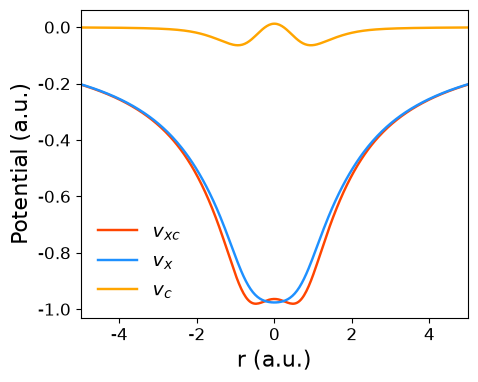

In [33]:
coords = gen_coords_1d(-15.0, 15.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv = vcoul_on_grid @ (mf_inv.vref_oep + mf_inv.vrest_oep)
vx_on_grid_ksinv = vcoul_on_grid @ mf_inv.vx_oep
vc_on_grid_ksinv = vcoul_on_grid @ mf_inv.vc_oep

plt.plot(coords[:, 2], vxc_on_grid_ksinv, color="orangered", label="$v_{xc}$")
plt.plot(coords[:, 2], vx_on_grid_ksinv, color="dodgerblue", label="$v_x$")
plt.plot(coords[:, 2], vc_on_grid_ksinv, color="orange", label="$v_c$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()

## 5. Error measures

When energy contributions are of interest, it is essential to evaluate the error measures of the KS inversion because large errors render energy contributions meaningless. These energy error measures are
- Hartree energy error
- External energy error
- Lieb error

You can read about these error measures in Ref. 6, along with strategies for reducing them.

I will repeat the example of the CO molecule from Ref. 6, for which the external energy error and the Lieb error are significantly reduced by addition of two additional tight basis functions to the auxiliary OEP basis. We will use the density matrix calculated with the aug-cc-pwCV5Z orbital basis set and stored in the `data/co_ccsd_aug-cc-pwCV5Z` directory.

In [34]:
ORBITAL_BASIS = "aug-cc-pwCV5Z"
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False

mf = scf.RHF(mol).density_fit().run()
print(f"Hartree-Fock total energy: {mf.e_tot:15.12f}")

Hartree-Fock total energy: -112.790271848668


In [35]:
dm_ref = np.load("../data/co_ccsd_aug-cc-pwCV5Z/dm.npy")

with open("../data/co_ccsd_aug-cc-pwCV5Z/energy.txt") as f:
    ref_energy = float(f.read())

In [36]:
# KS inversion
mf_inv = KSINV(mf, "aug-cc-pVDZ-RIFIT", dm_ref, ref_energy)
mf_inv.run(maxit=100, thr_fai_oep=5e-3)

ITER        ENERGY            RHS        MIXING
  0    -94.602923032794    8.687e-01    1.000e-01
  1    -96.472904412332    7.814e-01    1.000e-01
  2    -98.152418130362    7.032e-01    1.000e-01
  3    -99.661959003993    6.330e-01    1.000e-01
  4   -101.019451583503    5.698e-01    1.319e-01
  5   -102.627196247818    4.951e-01    1.817e-01
  6   -104.556764943671    4.056e-01    2.632e-01
  7   -106.818562725757    3.007e-01    3.961e-01
  8   -109.317144998685    1.849e-01    5.945e-01
  9   -111.597247828785    7.938e-02    8.174e-01
 10   -112.923970042220    1.726e-02    9.599e-01
 11   -113.257239924459    9.901e-04    9.977e-01
 12   -113.274637189659    6.214e-05    9.999e-01
 13   -113.275298979222    1.923e-06    1.000e+00
 14   -113.275306927545    8.167e-07    1.000e+00
 15   -113.275314745435    3.000e-08    1.000e+00
 16   -113.275314454827    1.294e-08    1.000e+00
 17   -113.275314578059    8.767e-10    1.000e+00
 18   -113.275314568781    2.228e-10    1.000e+00
 1

In [37]:
# make augmented OEP basis
aug_oepbasis = make_augmented_aux_basis(mol, "aug-cc-pVDZ-RIFIT", {"C": [180.0], "O": [600.0]})

# KS inversion
mf_inv_aug = KSINV(mf, aug_oepbasis, dm_ref, ref_energy)
mf_inv_aug.run(maxit=100, thr_fai_oep=5e-3)

ITER        ENERGY            RHS        MIXING
  0    -94.604617220491    8.687e-01    1.000e-01
  1    -96.474901012541    7.815e-01    1.000e-01
  2    -98.155023147242    7.032e-01    1.000e-01
  3    -99.665389954595    6.330e-01    1.000e-01
  4   -101.023853656698    5.698e-01    1.319e-01
  5   -102.632994054232    4.951e-01    1.817e-01
  6   -104.564590973021    4.056e-01    2.632e-01
  7   -106.829068920266    3.007e-01    3.961e-01
  8   -109.331147261414    1.849e-01    5.946e-01
  9   -111.614726039817    7.937e-02    8.175e-01
 10   -112.943023541486    1.728e-02    9.598e-01
 11   -113.279667426563    9.303e-04    9.978e-01
 12   -113.294538378069    7.649e-05    9.998e-01
 13   -113.295416831512    5.060e-06    1.000e+00
 14   -113.295376210919    1.248e-06    1.000e+00
 15   -113.295389380456    1.192e-07    1.000e+00
 16   -113.295388130481    2.325e-08    1.000e+00
 17   -113.295388374140    2.649e-09    1.000e+00
 18   -113.295388345582    4.506e-10    1.000e+00
 1

In [38]:
coords = gen_coords_1d(-15.0, 15.0, 1000)

vcoul_on_grid = coulomb_potential_on_grid(mf_inv.pmol, coords)
vxc_on_grid_ksinv = vcoul_on_grid @ (mf_inv.vref_oep + mf_inv.vrest_oep)

vcoul_on_grid = coulomb_potential_on_grid(mf_inv_aug.pmol, coords)
vxc_on_grid_ksinv_aug = vcoul_on_grid @ (mf_inv_aug.vref_oep + mf_inv_aug.vrest_oep)

ao = dft.numint.eval_ao(mf.mol, coords)
den_ref = dft.numint.eval_rho(mf.mol, ao, dm_ref)
den_ks = dft.numint.eval_rho(mf.mol, ao, mf_inv.mf.make_rdm1())
den_ks_aug = dft.numint.eval_rho(mf.mol, ao, mf_inv_aug.mf.make_rdm1())

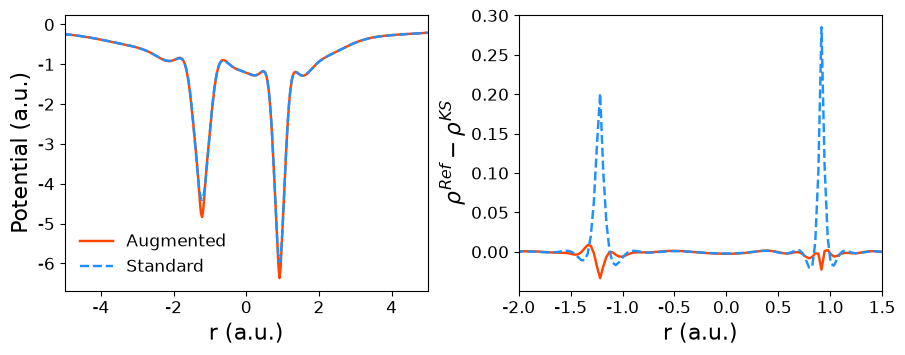

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))
plt.tight_layout()
plt.subplots_adjust(wspace=0.25, bottom=0.15, left=0.06)

axs[0].plot(coords[:, 2], vxc_on_grid_ksinv_aug, color="orangered", label="Augmented")
axs[0].plot(coords[:, 2], vxc_on_grid_ksinv, "--", color="dodgerblue", label="Standard")
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].set_xlim(-5, 5)
axs[0].legend(frameon=False, fontsize=12)

axs[1].plot(coords[:, 2], den_ref - den_ks_aug, color="orangered", label="Augmented")
axs[1].plot(coords[:, 2], den_ref - den_ks, "--", color="dodgerblue", label="Standard")
axs[1].set_ylabel(r"$\rho^{Ref}-\rho^{KS}$", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].set_xlim(-2, 1.5)

plt.show()

## 6. Concluding remarks
In this tutorial, we explored KS inversion calculations. We considered the inversion for closed- and open-shell systems.

For open-shell systems, in addition to the standard spin-unrestricted inversion, we looked at the spin-restricted inversion, which preserves the correct spin symmetry of a real electronic system. For both spin-unrestricted and spin-restricted KS inversions for open-shell systems, we also performed calculations with additional space-symmetrization, which forces the KS system to have the correct spatial symmetry of a real electronic system.

We considered an option to fix the orbital energy of the HOMO (or the orbital energies of the HOMOs for $\alpha$ and $\beta$ spins) to a predetermined value, which can be from experiment or from accurate total energy difference calculation of the ionization potential.

As a post-processing of calculations, we accessed and printed orbital energies resulting from KS inversion and explored how to plot the resulting potentials and densities.

Finally, we briefly discussed the energy error measures of KS inversion and the use of density fitting.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/PyOEP/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/PyOEP/)  If you found this tutorial helpful, consider ⭐-ing the repository.